In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
X = online_retail.data.features 
df = online_retail.data.original.copy()
  
# metadata 
print(online_retail.metadata) 
  
# variable information 
print(online_retail.variables) 

{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

In [2]:
import pandas as pd
import numpy as np

In [3]:
print(df.head())
print(df.describe())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -8

In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df.dropna(subset=['CustomerID'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Country'] = df['Country'].replace('EIRE', 'Ireland')

In [6]:
df[(df['Quantity'] == 0) & (df['UnitPrice'] == 0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [7]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [26]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Hour'] = df['InvoiceDate'].dt.hour
df['Day'] = df['InvoiceDate'].dt.day_name()
day_order = {
    'Monday': 1,
    'Tuesday': 2,
    'Wednesday': 3,
    'Thursday': 4,
    'Friday': 5,
    'Saturday': 6,
    'Sunday': 7
}

df['DayOrder'] = df['Day'].map(day_order)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID         Country  TotalPri

<Axes: title={'center': 'Monthly Revenue'}, xlabel='YearMonth'>

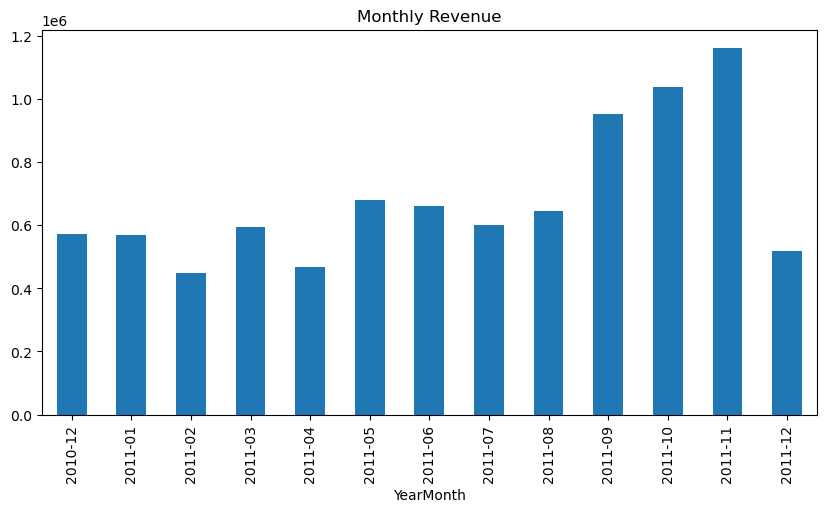

In [9]:
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()
monthly_revenue.plot(kind='bar', figsize=(10,5), title='Monthly Revenue')

<Axes: title={'center': 'Revenue by Day of Week'}, xlabel='Day'>

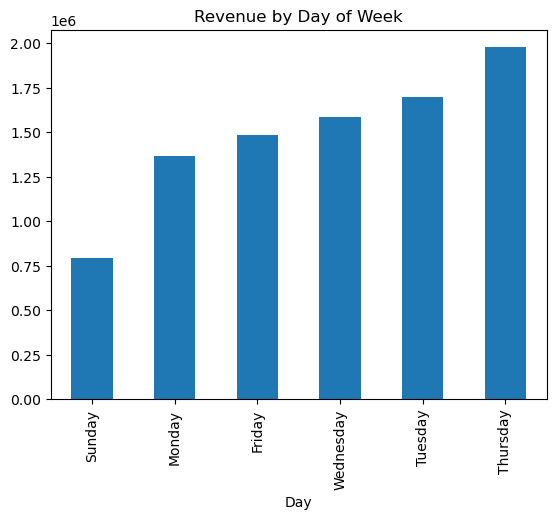

In [10]:
df.groupby('Day')['TotalPrice'].sum().sort_values().plot(kind='bar', title='Revenue by Day of Week')

<Axes: title={'center': 'Revenue by Hour'}, xlabel='Hour'>

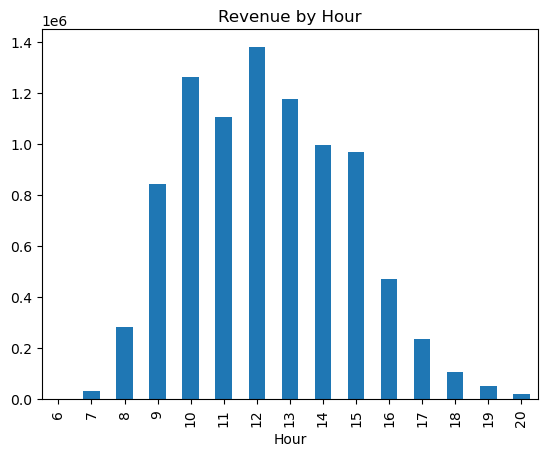

In [11]:
df.groupby('Hour')['TotalPrice'].sum().plot(kind='bar', title='Revenue by Hour')

In [12]:
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False)

customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalPrice, dtype: float64

In [13]:
customer_orders = df.groupby('CustomerID')['InvoiceNo'].nunique()

repeat_customers = (customer_orders > 1).sum()
one_time_customers = (customer_orders == 1).sum()

repeat_customers, one_time_customers

(2845, 1494)

In [31]:
snapshot_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [32]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4]).astype(int)

In [33]:
def segment_customer(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Best Customers'
    
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'High Value At Risk'
    
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'Loyal but Inactive'
    
    elif row['R_Score'] >= 3 and row['F_Score'] <= 2:
        return 'New Customers'
    
    elif row['R_Score'] <= 1 and row['F_Score'] <= 2 and row['M_Score'] <= 2:
        return 'Lost Customers'
    
    else:
        return 'Average Customers'

In [34]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

<Axes: title={'center': 'Customer Segments'}, xlabel='Segment'>

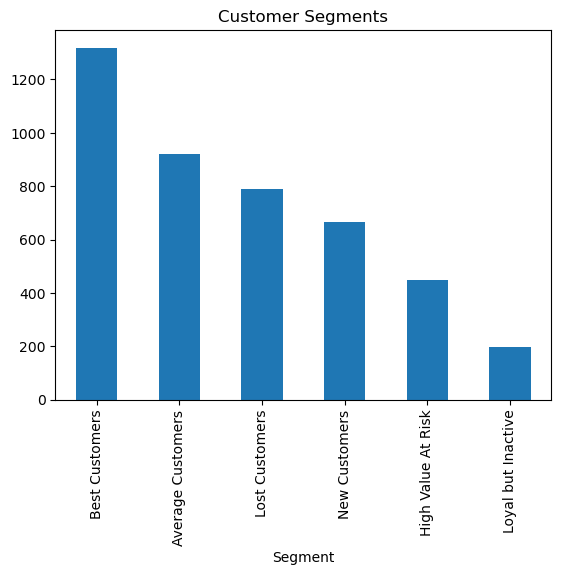

In [35]:
rfm['Segment'].value_counts().plot(kind='bar', title='Customer Segments')

In [36]:
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
Average Customers,87.880305,1.733406,706.912657
Best Customers,16.094769,9.378317,4932.935550
High Value At Risk,105.069196,4.687500,2136.950647
Lost Customers,256.794677,1.157161,269.109341
Loyal but Inactive,147.904040,3.010101,422.115157
New Customers,24.234234,1.447447,753.683514


In [37]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)

top_products.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: TotalPrice, dtype: float64

In [38]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

In [39]:
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

country_revenue.head(10)

Country
United Kingdom    7308391.554
Netherlands        285446.340
Ireland            265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: TotalPrice, dtype: float64

In [40]:
total_revenue = round(df['TotalPrice'].sum(), 2)
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = round(total_revenue / total_orders, 2)

total_revenue, total_orders, total_customers, avg_order_value

(8911407.9, 18536, 4339, 480.76)

In [41]:
monthly_revenue = (
    df.groupby('YearMonth', as_index=False)['TotalPrice']
    .sum()
    .rename(columns={'TotalPrice': 'Revenue'}))

product_summary = (
    df.groupby('Description', as_index=False)
    .agg(TotalRevenue=('TotalPrice', 'sum'),
         TotalQuantity=('Quantity', 'sum'),
         OrderCount=('InvoiceNo', 'nunique'))
    .sort_values('TotalRevenue', ascending=False))

country_summary = (
    df.groupby('Country', as_index=False)['TotalPrice']
    .sum()
    .rename(columns={'TotalPrice': 'Revenue'})
    .sort_values('Revenue', ascending=False))

customer_summary = rfm.copy()

kpi_summary = pd.DataFrame({
    'Metric': ['Total Revenue', 'Total Orders', 'Total Customers', 'Average Order Value'],
    'Value': [total_revenue, total_orders, total_customers, avg_order_value]})

In [42]:
df.to_csv('online_retail_cleaned.csv', index=True)
customer_summary.to_csv('customer_summary.csv', index=True)
monthly_revenue.to_csv('monthly_revenue.csv', index=False)
product_summary.to_csv('product_summary.csv', index=False)
country_summary.to_csv('country_summary.csv', index=False)
kpi_summary.to_csv('kpi_summary.csv', index=False)